# EMG Model 2 — 1D-CNN on Raw (Filtered) Windows (CPU-friendly)

This notebook trains **Model 2**: a **1D-CNN** that learns directly from **raw EMG windows** (after the *same* filtering/windowing as Model 1 Phase 2).

It supports:
- **Binary task**: Normal vs Abnormal
- **Multiclass task**: all bite states

**Expected project structure (same as Model 1):**
```
EMG_Project/
  data/
    meta.csv
    Normal_bite/*.xlsx
    Left_high_point/*.xlsx
    ...
  models/
  plots/
```

If your real data paths in `meta.csv` are absolute Windows paths, the notebook auto-fixes them to your current project folder (as long as the `data/...` relative structure is the same).


In [1]:
# (Optional) Install deps (run once per venv/kernel)
# For CPU-only PyTorch:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
# !pip install scikit-learn matplotlib tqdm


In [2]:
import os, re, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, iirnotch, detrend

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("torch:", torch.__version__, "cuda?", torch.cuda.is_available())


torch: 2.10.0+cpu cuda? False


## 0) Freeze preprocessing decisions (match Model 1 Phase 2)
If you change these, comparison vs Model 1 becomes meaningless.


In [3]:
# ===== Must match Model 1 Phase 2 =====
FS = 1000
WIN = int(0.25 * FS)      # 250ms => 250 samples at 1000Hz
STEP = int(0.125 * FS)    # 50% overlap => 125 samples
CH = ["LT", "LM", "RT", "RM"]

BP_LOW = 20
BP_HIGH = 450
NOTCH = 50
Q = 30
USE_NOTCH = True
RECTIFY = False

# Training config (CPU-friendly defaults)
TASK = "binary"   # "binary" or "multiclass"
BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-3
PATIENCE = 8      # early stopping patience on val macro-F1
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)


## 1) Load `meta.csv` and resolve file paths
`meta.csv` must have columns: `label, filepath`.


In [4]:
project_dir = Path.cwd()
data_dir = project_dir / "data"
meta_path = data_dir / "meta.csv"

# --- Load Phase2 config so Model2 matches Model1 preprocessing ---
import json

cfg_path = project_dir / "data" / "processed" / "config_used.json"
if cfg_path.exists():
    cfg = json.loads(cfg_path.read_text(encoding="utf-8"))
    FS = int(cfg.get("target_fs", 1000))
    WIN = int(round(float(cfg.get("window_sec", 0.25)) * FS))
    STEP = int(round(float(cfg.get("step_sec", 0.125)) * FS))
    CH = cfg.get("channels", ["LT", "LM", "RT", "RM"])
    print("Loaded Phase2 config_used.json:", cfg_path)
else:
    print("WARN: config_used.json not found; using notebook defaults")
    
print("Project:", project_dir)
print("Meta:", meta_path)

if not meta_path.exists():
    raise FileNotFoundError(
        f"Missing {meta_path}. Put this notebook inside your EMG_Project folder, "
        "or set `project_dir` manually."
    )

meta = pd.read_csv(meta_path)
assert {"label","filepath"}.issubset(meta.columns), f"meta.csv must contain label, filepath. got {meta.columns.tolist()}"
print("Rows:", len(meta), "Labels:", meta["label"].nunique())
meta.head()


Loaded Phase2 config_used.json: c:\Users\Qqtea\Downloads\EMG_Project\data\processed\config_used.json
Project: c:\Users\Qqtea\Downloads\EMG_Project
Meta: c:\Users\Qqtea\Downloads\EMG_Project\data\meta.csv
Rows: 52 Labels: 9


,label,filepath
0,Normal_bite,C:\Users\Qqtea\Downloads\EMG_Project\data\Norm...
1,Normal_bite,C:\Users\Qqtea\Downloads\EMG_Project\data\Norm...
2,Normal_bite,C:\Users\Qqtea\Downloads\EMG_Project\data\Norm...
3,Normal_bite,C:\Users\Qqtea\Downloads\EMG_Project\data\Norm...
4,Normal_bite,C:\Users\Qqtea\Downloads\EMG_Project\data\Norm...


In [5]:
def resolve_filepath(fp_str: str, project_dir: Path) -> Path:
    # 1) try as-is
    p = Path(fp_str)
    if p.exists():
        return p

    s = str(fp_str).replace("/", "\\")
    # find "\data\..."
    m = re.search(r"\\data\\(.+)$", s, flags=re.IGNORECASE)
    if m:
        rel = m.group(1).replace("\\", os.sep)
        cand = project_dir / "data" / rel
        if cand.exists():
            return cand

    # if stored as relative already
    p2 = (project_dir / fp_str).resolve()
    if p2.exists():
        return p2

    # last resort: try filename-only search
    name = Path(fp_str).name
    hits = list((project_dir / "data").rglob(name))
    if len(hits) == 1:
        return hits[0]

    return Path(fp_str)

meta["file_resolved"] = meta["filepath"].apply(lambda x: str(resolve_filepath(str(x), project_dir)))
missing = meta[~meta["file_resolved"].apply(lambda x: Path(x).exists())]
print("Missing files:", len(missing))
if len(missing) > 0:
    display(missing.head(10))


Missing files: 0


## 2) Build raw-window dataset (Option A output)
From each `.xlsx`:
- filter each channel (bandpass + optional notch)
- slide windows (WIN, STEP)
- per-window z-normalize (per channel)
- save:
  - `X_raw`: (N_windows, 4, WIN) float32
  - `y`: int labels
  - `file_ids`: which Excel file each window came from
  - `meta_windows.csv` for debugging / leakage-free splits


In [6]:
# Filters (precompute)
b_bp, a_bp = butter(4, [BP_LOW, BP_HIGH], btype="bandpass", fs=FS)
b_notch, a_notch = iirnotch(NOTCH, Q, fs=FS)

def filt_1d(sig: np.ndarray) -> np.ndarray:
    sig = np.asarray(sig, dtype=float)
    sig = detrend(sig, type="constant")      # remove DC
    sig = filtfilt(b_bp, a_bp, sig)          # bandpass
    if USE_NOTCH:
        sig = filtfilt(b_notch, a_notch, sig)
    if RECTIFY:
        sig = np.abs(sig)
    return sig.astype(np.float32)

def rmsnorm_window(w: np.ndarray) -> np.ndarray:
    """
    Normalize the whole window by a single scale (global RMS),
    so channel-to-channel amplitude ratios (asymmetry) are preserved.
    w shape: (WIN, 4)
    """
    w = np.asarray(w, dtype=np.float32)
    # remove DC per channel (safe)
    w = w - w.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(w * w)) + 1e-6  # one scalar for all channels
    return (w / scale).astype(np.float32)

def build_label_map(meta: pd.DataFrame, task: str):
    labels = sorted(meta["label"].astype(str).unique().tolist())
    if task == "binary":
        label_map = {lab: (0 if lab.lower() == "normal_bite" else 1) for lab in labels}
        class_names = ["Normal", "Abnormal"]
    else:
        label_map = {lab: i for i, lab in enumerate(labels)}
        class_names = labels
    return label_map, class_names

label_map, class_names = build_label_map(meta, TASK)
print("TASK:", TASK)
print("Classes:", class_names)


TASK: binary
Classes: ['Normal', 'Abnormal']


In [7]:
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, total=None):
        return x

def export_raw_windows(meta: pd.DataFrame, task: str, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)

    label_map, class_names = build_label_map(meta, task)

    X_list, y_list, file_list = [], [], []
    meta_rows = []

    for _, row in tqdm(meta.iterrows(), total=len(meta)):
        lab = str(row["label"])
        fp = Path(row["file_resolved"])

        if not fp.exists():
            continue

        df = pd.read_excel(fp)  # requires openpyxl
        needed = ["Time"] + CH
        if any(c not in df.columns for c in needed):
            continue

        t = df["Time"].to_numpy()
        sig = np.stack([df[c].to_numpy() for c in CH], axis=1)  # (N,4)

        sig_f = np.stack([filt_1d(sig[:, i]) for i in range(sig.shape[1])], axis=1).astype(np.float32)

        n = sig_f.shape[0]
        if n < WIN:
            continue

        y = int(label_map[lab])

        for start in range(0, n - WIN + 1, STEP):
            end = start + WIN
            w = sig_f[start:end, :]            # (WIN,4)
            w = rmsnorm_window(w)                # (WIN,4)
            w = w.T                            # -> (4, WIN) for Conv1d

            X_list.append(w)
            y_list.append(y)
            file_list.append(str(fp))

            meta_rows.append({
                "file": str(fp),
                "label_str": lab,
                "label": y,
                "start_idx": int(start),
                "end_idx": int(end),
                "start_time": float(t[start]),
                "end_time": float(t[end-1]),
            })

    X = np.stack(X_list, axis=0).astype(np.float32)  # (N,4,WIN)
    y = np.array(y_list, dtype=np.int64)
    file_ids = np.array(file_list, dtype=str)

    npz_path = out_dir / f"emg_raw_{task}.npz"
    np.savez_compressed(npz_path, X=X, y=y, file_ids=file_ids, class_names=np.array(class_names, dtype=str))

    meta_w = pd.DataFrame(meta_rows)
    meta_path = out_dir / f"meta_windows_{task}.csv"
    meta_w.to_csv(meta_path, index=False)

    label_path = out_dir / f"label_map_{task}.json"
    with open(label_path, "w", encoding="utf-8") as f:
        json.dump(
            {"task": task, "class_names": class_names, "label_map": label_map,
             "fs": FS, "win": WIN, "step": STEP,
             "bp": [BP_LOW, BP_HIGH], "notch": NOTCH, "use_notch": USE_NOTCH,
             "rectify": RECTIFY},
            f, indent=2
        )

    print("Saved:", npz_path)
    print("Saved:", meta_path)
    print("Saved:", label_path)
    print("X:", X.shape, "y:", y.shape, "files:", len(np.unique(file_ids)))
    if y.size:
        print("y counts:", np.bincount(y))
    return npz_path, meta_path, label_path

processed_dir = data_dir / "processed_model2"
npz_path, meta_windows_path, label_json_path = export_raw_windows(meta, TASK, processed_dir)


Saved: c:\Users\Qqtea\Downloads\EMG_Project\data\processed_model2\emg_raw_binary.npz
Saved: c:\Users\Qqtea\Downloads\EMG_Project\data\processed_model2\meta_windows_binary.csv
Saved: c:\Users\Qqtea\Downloads\EMG_Project\data\processed_model2\label_map_binary.json
X: (364, 4, 250) y: (364,) files: 52
y counts: [ 84 280]


## 3) File-wise split (no leakage)
Split by **file**, then select windows belonging to those files.


In [8]:
def file_wise_split(file_ids: np.ndarray, y: np.ndarray, test_size=0.2, val_size=0.2, seed=42):
    unique_files = np.unique(file_ids)

    # file-level label = majority label of windows in that file
    file_to_label = {}
    for f in unique_files:
        ys = y[file_ids == f]
        vals, counts = np.unique(ys, return_counts=True)
        file_to_label[f] = int(vals[np.argmax(counts)])
    file_labels = np.array([file_to_label[f] for f in unique_files])

    # split test
    try:
        train_files, test_files = train_test_split(
            unique_files, test_size=test_size, random_state=seed, stratify=file_labels
        )
    except ValueError:
        train_files, test_files = train_test_split(
            unique_files, test_size=test_size, random_state=seed, shuffle=True
        )

    # split val from train
    train_labels = np.array([file_to_label[f] for f in train_files])
    val_ratio = val_size / (1.0 - test_size)
    try:
        train_files, val_files = train_test_split(
            train_files, test_size=val_ratio, random_state=seed, stratify=train_labels
        )
    except ValueError:
        train_files, val_files = train_test_split(
            train_files, test_size=val_ratio, random_state=seed, shuffle=True
        )

    return train_files, val_files, test_files

ds = np.load(npz_path, allow_pickle=True)
X = ds["X"].astype(np.float32)      # (N,4,WIN)
y = ds["y"].astype(np.int64)
file_ids = ds["file_ids"].astype(str)
class_names = ds["class_names"].astype(str).tolist()

train_files, val_files, test_files = file_wise_split(file_ids, y, test_size=0.2, val_size=0.2, seed=SEED)

train_mask = np.isin(file_ids, train_files)
val_mask   = np.isin(file_ids, val_files)
test_mask  = np.isin(file_ids, test_files)

X_tr, y_tr = X[train_mask], y[train_mask]
X_va, y_va = X[val_mask], y[val_mask]
X_te, y_te = X[test_mask], y[test_mask]

print("Windows:", X.shape[0], "Files:", len(np.unique(file_ids)))
print("Train/Val/Test windows:", X_tr.shape[0], X_va.shape[0], X_te.shape[0])
print("Train/Val/Test files:", len(train_files), len(val_files), len(test_files))
if y_tr.size: print("Train label counts:", np.bincount(y_tr))
if y_va.size: print("Val   label counts:", np.bincount(y_va))
if y_te.size: print("Test  label counts:", np.bincount(y_te))


Windows: 364 Files: 52
Train/Val/Test windows: 210 77 77
Train/Val/Test files: 30 11 11
Train label counts: [ 49 161]
Val   label counts: [14 63]
Test  label counts: [21 56]


## 4) PyTorch Dataset / DataLoader
`X` is `(N, 4, WIN)` already (channel-first).


In [9]:
import numpy as np
import torch
from torch.utils.data import Dataset

class EMGWindowDataset(Dataset):
    """
    X: numpy array
       either (N, WIN, C) or (N, C, WIN)
    y: numpy int array of shape (N,)
    """
    def __init__(self, X, y):
        self.X = np.asarray(X)
        self.y = np.asarray(y).astype(np.int64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        # ensure float32 torch tensor
        x = torch.tensor(x, dtype=torch.float32)
        y = int(self.y[idx])
        return x, y

In [10]:
from torch.utils.data import WeightedRandomSampler

train_ds = EMGWindowDataset(X_tr, y_tr)
val_ds   = EMGWindowDataset(X_va, y_va)
test_ds  = EMGWindowDataset(X_te, y_te)

# --- Build sample weights (inverse class frequency) ---
counts = np.bincount(y_tr)  # e.g. [normal_count, abnormal_count]
counts = np.maximum(counts, 1)
class_weights = 1.0 / counts
sample_weights = class_weights[y_tr]

print("Train counts:", counts.tolist())
print("Class weights:", class_weights.tolist())

sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False, drop_last=False)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Train counts: [49, 161]
Class weights: [0.02040816326530612, 0.006211180124223602]


## 5) Model 2 — 1D-CNN (small, CPU-friendly)


In [11]:
import torch

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# class names (binary -> 2 classes)
# If you already have class_names elsewhere, keep that one.
if "class_names" not in globals():
    class_names = ["Normal", "Abnormal"]
print("class_names:", class_names)

Using device: cpu
class_names: ['Normal', 'Abnormal']


In [12]:
class SmallEMGCNN(nn.Module):
    def __init__(self, n_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(4, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),  # -> (B,128,1)
            nn.Flatten(),             # -> (B,128)
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.net(x)

model = SmallEMGCNN(n_classes=len(class_names)).to(device)
model


SmallEMGCNN(
  (net): Sequential(
    (0): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Dropout(p=0.3, inplace=False)
    (14): Linear(in_features=128, out_features=2, bias=True)
  )
)

## 6) Train with early stopping on validation macro-F1


In [13]:
print("X_tr shape:", X_tr.shape)  # should be (N, 4, WIN) for Conv1d typical

X_tr shape: (210, 4, 250)


In [14]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [15]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    all_y, all_pred = [], []
    total_loss = 0.0
    n = 0

    criterion = nn.CrossEntropyLoss()

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        n += xb.size(0)

        pred = torch.argmax(logits, dim=1)
        all_y.append(yb.detach().cpu().numpy())
        all_pred.append(pred.detach().cpu().numpy())

    all_y = np.concatenate(all_y) if all_y else np.array([])
    all_pred = np.concatenate(all_pred) if all_pred else np.array([])

    avg_loss = total_loss / max(n, 1)
    acc = accuracy_score(all_y, all_pred) if n else 0.0
    f1m = f1_score(all_y, all_pred, average="macro") if n else 0.0

    return avg_loss, acc, f1m


optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_f1 = -1.0
best_state = None
pat = 0
history = []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer=optimizer)
    va_loss, va_acc, va_f1 = run_epoch(model, val_loader, optimizer=None)

    history.append((epoch, tr_loss, tr_acc, tr_f1, va_loss, va_acc, va_f1))

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} | "
        f"val loss {va_loss:.4f} acc {va_acc:.3f} f1 {va_f1:.3f}"
    )

    if va_f1 > best_f1 + 1e-4:
        best_f1 = va_f1
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        pat = 0
    else:
        pat += 1
        if pat >= PATIENCE:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

models_dir = project_dir / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / f"model2_cnn_{TASK}_v3.pt"

torch.save(
    {
        "state_dict": model.state_dict(),
        "class_names": class_names,
    },
    model_path,
)

print("Saved model:", model_path)

Epoch 01 | train loss 0.6282 acc 0.648 f1 0.646 | val loss 0.6201 acc 0.818 f1 0.450
Epoch 02 | train loss 0.5976 acc 0.695 f1 0.692 | val loss 0.5335 acc 0.701 f1 0.511
Epoch 03 | train loss 0.5460 acc 0.714 f1 0.714 | val loss 0.5732 acc 0.662 f1 0.586
Epoch 04 | train loss 0.5475 acc 0.719 f1 0.716 | val loss 0.5079 acc 0.675 f1 0.585
Epoch 05 | train loss 0.4817 acc 0.800 f1 0.800 | val loss 0.5446 acc 0.662 f1 0.586
Epoch 06 | train loss 0.4492 acc 0.786 f1 0.785 | val loss 0.5569 acc 0.675 f1 0.597
Epoch 07 | train loss 0.4804 acc 0.790 f1 0.790 | val loss 0.4968 acc 0.727 f1 0.595
Epoch 08 | train loss 0.3572 acc 0.905 f1 0.905 | val loss 0.7617 acc 0.597 f1 0.562
Epoch 09 | train loss 0.2972 acc 0.900 f1 0.900 | val loss 0.7771 acc 0.584 f1 0.557
Epoch 10 | train loss 0.2330 acc 0.962 f1 0.962 | val loss 0.4368 acc 0.805 f1 0.711
Epoch 11 | train loss 0.1757 acc 0.971 f1 0.971 | val loss 0.3793 acc 0.805 f1 0.617
Epoch 12 | train loss 0.1332 acc 0.990 f1 0.990 | val loss 0.8866

## 7) Evaluate on test set + confusion matrix


TEST | loss 0.3024 acc 0.896 macroF1 0.873

Classification report:
              precision    recall  f1-score   support

      Normal       0.78      0.86      0.82        21
    Abnormal       0.94      0.91      0.93        56

    accuracy                           0.90        77
   macro avg       0.86      0.88      0.87        77
weighted avg       0.90      0.90      0.90        77



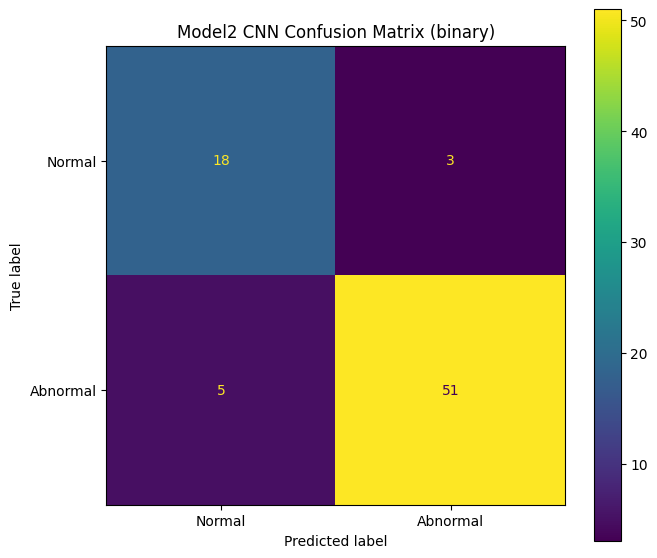

Saved: c:\Users\Qqtea\Downloads\EMG_Project\plots\cm_model2_cnn_binary.png


In [16]:
te_loss, te_acc, te_f1 = run_epoch(model, test_loader, optimizer=None)
print(f"TEST | loss {te_loss:.4f} acc {te_acc:.3f} macroF1 {te_f1:.3f}")

model.eval()
all_y, all_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        all_pred.append(pred)
        all_y.append(yb.numpy())

y_true = np.concatenate(all_y) if all_y else np.array([])
y_pred = np.concatenate(all_pred) if all_pred else np.array([])

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
fig_w = 7 if TASK == "binary" else 12
fig_h = 6 if TASK == "binary" else 10
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format="d")
ax.set_title(f"Model2 CNN Confusion Matrix ({TASK})")
if TASK != "binary":
    plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plots_dir = project_dir / "plots"
plots_dir.mkdir(exist_ok=True)
cm_path = plots_dir / f"cm_model2_cnn_{TASK}.png"
plt.savefig(cm_path, dpi=220)
plt.show()
print("Saved:", cm_path)


## 8) Demo inference on a single `.xlsx` file (majority vote over windows)
Set `demo_xlsx` to a file in your `data/...` folders.


In [17]:
def predict_file_xlsx(model, xlsx_path: Path):
    df = pd.read_excel(xlsx_path)
    needed = ["Time"] + CH
    if any(c not in df.columns for c in needed):
        raise ValueError(f"Missing columns in {xlsx_path.name}. Need {needed}.")

    t = df["Time"].to_numpy()
    sig = np.stack([df[c].to_numpy() for c in CH], axis=1)  # (N,4)
    sig_f = np.stack([filt_1d(sig[:, i]) for i in range(4)], axis=1).astype(np.float32)

    n = sig_f.shape[0]
    if n < WIN:
        raise ValueError(f"File too short: len={n}, WIN={WIN}")

    windows = []
    for start in range(0, n - WIN + 1, STEP):
        end = start + WIN
        w = rmsnorm_window(sig_f[start:end, :]).T  # (4,WIN)
        windows.append(w)

    Xw = torch.from_numpy(np.stack(windows, axis=0)).float().to(device)

    model.eval()
    with torch.no_grad():
        logits = model(Xw)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred = np.argmax(probs, axis=1)

    vals, counts = np.unique(pred, return_counts=True)
    maj = int(vals[np.argmax(counts)])
    maj_name = class_names[maj]

    # asymmetry summary (RMS)
    rms_ch = np.sqrt(np.mean(sig_f**2, axis=0))  # (4,)
    left = rms_ch[0] + rms_ch[1]
    right = rms_ch[2] + rms_ch[3]
    lr_ratio = float((left + 1e-8) / (right + 1e-8))
    asym_index = float((left - right) / (left + right + 1e-8))

    return {
        "file": str(xlsx_path),
        "n_windows": len(windows),
        "majority_class_id": maj,
        "majority_class": maj_name,
        "window_pred_counts": {class_names[int(v)]: int(c) for v, c in zip(vals, counts)},
        "left_right_ratio": lr_ratio,
        "asym_index": asym_index,
        "rms_LTRMRM": rms_ch.tolist(),
    }

# Example:
# demo_xlsx = data_dir / "Left_chewing" / "Left_chewing_1.xlsx"
demo_xlsx = None

if demo_xlsx is not None and Path(demo_xlsx).exists():
    predict_file_xlsx(model, Path(demo_xlsx))
else:
    print("Set demo_xlsx to a real .xlsx path under your data/ folders.")


Set demo_xlsx to a real .xlsx path under your data/ folders.


## Notes for your report
- Model 1 = **feature-based baseline** (interpretable, fast)
- Model 2 = **CNN on raw windows** (can learn richer temporal patterns)
- Keep preprocessing identical and use file-wise split for a fair comparison.
